<a href="https://colab.research.google.com/github/yvonne12003/-25RP19168-studentmis-repo/blob/main/AITS_Training_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Personalized Tourism Recommendation System For Rwanda
**Google Colab Training Notebook**  
Author: Munyakayanza Yvonne | RP Musanze College | April 2026

## Section 0: Install Dependencies

In [1]:
!pip install pandas numpy scikit-learn openpyxl matplotlib seaborn -q
print('Done')

Done


## Section 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle, json
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, r2_score, mean_squared_error,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, accuracy_score
)
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


## Section 2: Upload and Load Dataset

In [3]:
from google.colab import files
import io
print('Please upload your UPDATED_DATASET.xlsx file:')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(io.BytesIO(uploaded[filename]))
print(f'Dataset loaded: {len(df_raw)} rows, {len(df_raw.columns)} columns')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()

Please upload your UPDATED_DATASET.xlsx file:


Saving UPDATED_DATASET.xlsx to UPDATED_DATASET.xlsx
Dataset loaded: 1000 rows, 28 columns
Columns: ['number', 'attraction_id', 'area of attraction', 'category', 'province', 'district', 'location_desc', 'description', 'activities', 'interest_tags', 'travel means', 'accommodation', 'time spent', 'min_duration_hrs', 'max_duration_hrs', 'visiting only budget', 'extra_cost', 'total_budget', 'infrastructure', 'medical health support', 'security', 'area development', 'season', 'tour guide', 'nationality', 'visitor_type', 'rating', 'accessibility']


,number,attraction_id,area of attraction,category,province,district,location_desc,description,activities,interest_tags,...,infrastructure,medical health support,security,area development,season,tour guide,nationality,visitor_type,rating,accessibility
0,1,ATT-008,Ntarama Genocide Memorial,Historical,Eastern Province,Bugesera,"Bugesera District, south of Kigali",A church-turned-memorial site preserving the r...,memorial tour|guided historical walk|museum visit,historical|cultural,...,medium,available,secure,rural,rainy,available,France,international,2.9,Medium
1,2,ATT-005,Lake Kivu - Karongi,Relaxation,Western Province,Karongi,"Karongi District, western Rwanda on Lake Kivu ...",Scenic freshwater lake on the Congo border off...,beach relaxation|kayaking|island tours|water s...,leisure|adventure|relaxation,...,medium,available,secure,urban,dry,available,Uganda,regional,3.5,Difficult
2,3,ATT-002,Nyungwe National Park,Nature,Southern Province,Nyamasheke,"Nyamasheke District, southwestern Rwanda",One of Africa's oldest rainforests featuring c...,chimpanzee trekking|canopy walk|bird watching|...,wildlife|eco-tourism|adventure|nature,...,medium,available,secure,rural,rainy,available,Kenya,regional,3.5,Difficult
3,4,ATT-008,Ntarama Genocide Memorial,Historical,Eastern Province,Bugesera,"Bugesera District, south of Kigali",A church-turned-memorial site preserving the r...,memorial tour|guided historical walk|museum visit,historical|cultural,...,medium,available,secure,rural,dry,available,Germany,international,3.1,Medium
4,5,ATT-008,Ntarama Genocide Memorial,Historical,Eastern Province,Bugesera,"Bugesera District, south of Kigali",A church-turned-memorial site preserving the r...,memorial tour|guided historical walk|museum visit,historical|cultural,...,medium,available,secure,rural,dry,available,Kenya,regional,2.7,Medium


## Section 3: Data Exploration

In [4]:
print('=== DATASET OVERVIEW ===')
print(f'Shape: {df_raw.shape}')
print(f'Attractions: {df_raw["area of attraction"].nunique()}')
print()
print('--- Category Distribution ---')
print(df_raw['category'].value_counts())
print()
print('--- Visitor Types ---')
print(df_raw['visitor_type'].value_counts())
print()
print('--- Seasons ---')
print(df_raw['season'].value_counts())
print()
print('--- Missing Values ---')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values')
print()
print('--- Basic Statistics ---')
df_raw[['visiting only budget','total_budget','rating']].describe()

=== DATASET OVERVIEW ===
Shape: (1000, 28)
Attractions: 18

--- Category Distribution ---
category
Historical    346
Nature        204
Relaxation    166
Cultural      149
Wildlife      135
Name: count, dtype: int64

--- Visitor Types ---
visitor_type
international    505
regional         377
domestic         118
Name: count, dtype: int64

--- Seasons ---
season
rainy    515
dry      485
Name: count, dtype: int64

--- Missing Values ---
No missing values

--- Basic Statistics ---


,visiting only budget,total_budget,rating
count,1000.000000,1000.000000,1000.000000
mean,30.935000,78.540000,3.203900
std,32.445547,42.817891,0.407383
min,0.000000,25.000000,2.500000
25%,0.000000,45.000000,2.900000
50%,20.000000,65.000000,3.200000
75%,45.000000,105.000000,3.500000
max,100.000000,180.000000,4.300000


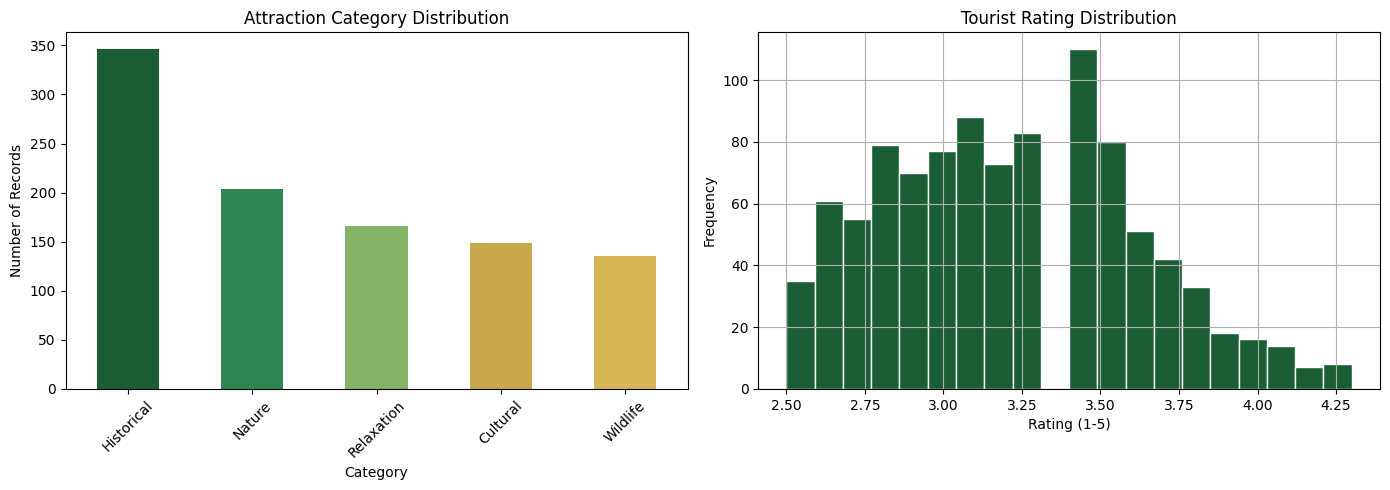

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_raw['category'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#1B5E35','#2D8653','#82b366','#C9A84C','#d6b656'])
axes[0].set_title('Attraction Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Records')
axes[0].tick_params(axis='x', rotation=45)
df_raw['rating'].hist(bins=20, ax=axes[1], color='#1B5E35', edgecolor='white')
axes[1].set_title('Tourist Rating Distribution')
axes[1].set_xlabel('Rating (1-5)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Section 4: Data Cleaning

In [6]:
df = df_raw.copy()

# 4.1 Fill missing values
df['description']   = df['description'].fillna('')
df['activities']    = df['activities'].fillna('')
df['interest_tags'] = df['interest_tags'].fillna('')
df['nationality']   = df['nationality'].fillna('Other')
df['visitor_type']  = df['visitor_type'].fillna('international')
df['season']        = df['season'].fillna('dry')
df['accommodation'] = df['accommodation'].fillna('No')
df['rating']        = df['rating'].fillna(df['rating'].mean())

# 4.2 Add optional columns if missing
if 'security' not in df.columns:
    df['security'] = 'secure'
if 'tour guide' not in df.columns:
    df['tour guide'] = 'available'
if 'location_desc' not in df.columns:
    df['location_desc'] = df['district'] + ', ' + df['province']
if 'attraction_id' not in df.columns:
    df['attraction_id'] = 'ATT-' + df['area of attraction'].rank(method='dense').astype(int).astype(str).str.zfill(3)

# 4.3 Derive cost columns from budget data
if 'cost_low_usd' not in df.columns:
    df['cost_low_usd']  = df.groupby('area of attraction')['visiting only budget'].transform('min')
    df['cost_high_usd'] = df.groupby('area of attraction')['total_budget'].transform('max')
    print('Derived cost_low_usd and cost_high_usd from budget data.')

# 4.4 Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows. Remaining: {len(df)}')

# 4.5 Clip numeric ranges
df['rating'] = df['rating'].clip(1, 5)
df['visiting only budget'] = df['visiting only budget'].clip(0, None)
df['total_budget'] = df['total_budget'].clip(0, None)

print(f'Final shape: {df.shape}')
print(f'Attractions: {df["area of attraction"].nunique()}')
print(f'Categories: {df["category"].unique()}')
print('Data cleaning complete.')

Derived cost_low_usd and cost_high_usd from budget data.
Removed 0 duplicate rows. Remaining: 1000
Final shape: (1000, 30)
Attractions: 18
Categories: ['Historical' 'Relaxation' 'Nature' 'Wildlife' 'Cultural']
Data cleaning complete.


## Section 5: Feature Engineering

In [7]:
CAT_COLS = ['accommodation','infrastructure','area development',
            'travel means','time spent','visitor_type','season','nationality']
NUM_RAW  = ['visiting only budget','extra_cost','total_budget',
            'cost_low_usd','cost_high_usd','min_duration_hrs','max_duration_hrs',
            'rating','budget_above_low','budget_gap_to_ideal','budget_comfortable',
            'extra_pct_of_total','cost_range','acc_x_extra','acc_x_rating',
            'acc_x_twoday','extra_x_rating','infra_x_urban','infra_x_acc',
            'att_target_enc','cat_target_enc','prov_target_enc','dist_target_enc',
            'vtype_budget_ratio']

# 5.1 Compute suitability score from real factors (not from dataset column)
r_min, r_max = df['rating'].min(), df['rating'].max()
rating_score = (df['rating'] - r_min) / (r_max - r_min + 1e-9)
can_visit    = (df['visiting only budget'] >= df['cost_low_usd']).astype(float)
comfortable  = (df['total_budget'] >= df['cost_low_usd']).astype(float)
shortfall    = np.maximum(0, df['cost_low_usd'] - df['visiting only budget'])
penalty      = np.minimum(1.0, shortfall / (df['cost_low_usd'] + 1))
budget_score = (can_visit * 0.5 + comfortable * 0.5 - penalty * 0.4).clip(0, 1)
tourist_hrs  = df['time spent'].map({'1 day': 8, '2 days': 16}).fillna(8)
dur_ok       = ((tourist_hrs >= df['min_duration_hrs']) & (tourist_hrs <= df['max_duration_hrs'])).astype(float)
dur_partial  = np.where(tourist_hrs < df['min_duration_hrs'], tourist_hrs / (df['min_duration_hrs'] + 1), 1.0)
duration_score = (dur_ok * 0.7 + dur_partial * 0.3).clip(0, 1)
vtype_avg    = df.groupby('visitor_type')['visiting only budget'].transform('mean')
vtype_score  = (df['visiting only budget'] / (vtype_avg + 1)).clip(0, 2) / 2
raw = 0.40*rating_score + 0.35*budget_score + 0.15*duration_score + 0.10*vtype_score
s_min, s_max = raw.min(), raw.max()
df['suitability_score'] = (50 + 50*(raw - s_min)/(s_max - s_min + 1e-9)).round(2)
print(f'Suitability score: min={df["suitability_score"].min():.1f}, mean={df["suitability_score"].mean():.1f}, max={df["suitability_score"].max():.1f}')

# 5.2 Target encoding
att_m  = df.groupby('area of attraction')['suitability_score'].mean()
cat_m  = df.groupby('category')['suitability_score'].mean()
prov_m = df.groupby('province')['suitability_score'].mean()
dist_m = df.groupby('district')['suitability_score'].mean()
df['att_target_enc']  = df['area of attraction'].map(att_m).fillna(att_m.mean())
df['cat_target_enc']  = df['category'].map(cat_m).fillna(cat_m.mean())
df['prov_target_enc'] = df['province'].map(prov_m).fillna(prov_m.mean())
df['dist_target_enc'] = df['district'].map(dist_m).fillna(dist_m.mean())

# 5.3 Label encoding
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col+'_e'] = le.fit_transform(df[col].astype(str).str.lower().str.strip())
    encoders[col] = le

# 5.4 Binary flags
df['acc_flag']   = (df['accommodation'] == 'Yes').astype(float)
df['twoday']     = (df['time spent'] == '2 days').astype(float)
df['high_infra'] = (df['infrastructure'] == 'high').astype(float)
df['urban']      = (df['area development'] == 'urban').astype(float)

# 5.5 Budget features
df['budget_in_range']     = (df['visiting only budget'] >= df['cost_low_usd']).astype(float)
df['budget_comfortable']  = (df['total_budget'] >= df['cost_low_usd']).astype(float)
df['budget_above_low']    = np.maximum(0, df['visiting only budget'] - df['cost_low_usd'])
df['budget_gap_to_ideal'] = np.maximum(0, df['total_budget'] - df['visiting only budget'])
df['extra_pct_of_total']  = df['extra_cost'] / (df['total_budget'] + 1)
df['cost_range']          = df['cost_high_usd'] - df['cost_low_usd']
df['vtype_budget_ratio']  = (df['visiting only budget'] / (vtype_avg + 1)).clip(0, 3)

# 5.6 Interaction features
df['acc_x_extra']    = df['acc_flag'] * df['extra_cost']
df['acc_x_rating']   = df['acc_flag'] * df['rating']
df['acc_x_twoday']   = df['acc_flag'] * df['twoday']
df['extra_x_rating'] = df['extra_cost'] * df['rating']
df['infra_x_urban']  = df['high_infra'] * df['urban']
df['infra_x_acc']    = df['high_infra'] * df['acc_flag']

# 5.7 Normalize numeric features
NUM_NORM = [c+'_n' for c in NUM_RAW]
BIN_COLS = ['acc_flag','twoday','high_infra','urban','budget_in_range']
scaler = MinMaxScaler()
df[NUM_NORM] = scaler.fit_transform(df[NUM_RAW].fillna(0))
df['visiting_budget_norm'] = df['visiting only budget_n']
df['total_budget_norm']    = df['total_budget_n']
df['rating_norm']          = df['rating_n']

RF_FEATURES = [c+'_e' for c in CAT_COLS] + BIN_COLS + NUM_NORM
print(f'Total RF features: {len(RF_FEATURES)}')
print('Feature engineering complete.')

Suitability score: min=50.0, mean=70.0, max=100.0
Total RF features: 37
Feature engineering complete.


## Section 6: Split Data — 80% Train / 20% Test

Total samples  : 1000
Training set   : 800 samples (80%)
Testing set    : 200 samples  (20%)
Features       : 37


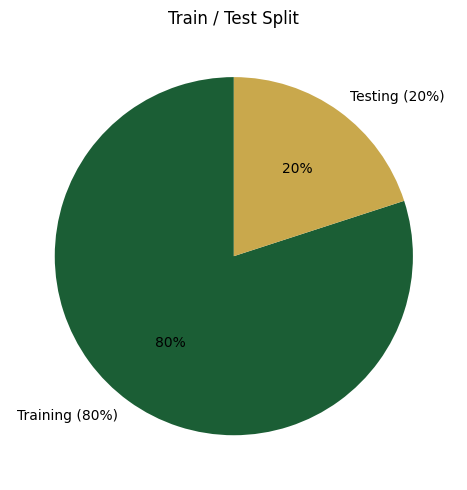

In [8]:
X = df[RF_FEATURES].fillna(0)
y = df['suitability_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f'Total samples  : {len(df)}')
print(f'Training set   : {len(X_train)} samples ({len(X_train)/len(df)*100:.0f}%)')
print(f'Testing set    : {len(X_test)} samples  ({len(X_test)/len(df)*100:.0f}%)')
print(f'Features       : {X_train.shape[1]}')

plt.figure(figsize=(5, 5))
plt.pie([len(X_train), len(X_test)],
        labels=['Training (80%)', 'Testing (20%)'],
        colors=['#1B5E35', '#C9A84C'],
        autopct='%1.0f%%', startangle=90)
plt.title('Train / Test Split')
plt.tight_layout()
plt.show()

## Section 7: Train TF-IDF (Content-Based Filtering — 55%)

In [9]:
df['cbf_text'] = (
    df['interest_tags'].fillna('').str.replace('|', ' ', regex=False) + ' ' +
    df['activities'].fillna('').str.replace('|', ' ', regex=False) + ' ' +
    df['category'].fillna('') + ' ' + df['description'].fillna('') + ' ' +
    df['province'].fillna('') + ' ' + df['district'].fillna('')
)
texts  = df.drop_duplicates('area of attraction').set_index('area of attraction')['cbf_text']
tfidf  = TfidfVectorizer(max_features=800, ngram_range=(1,2), stop_words='english', sublinear_tf=True)
matrix = tfidf.fit_transform(texts)
sim    = cosine_similarity(matrix, matrix)
idx    = {n: i for i, n in enumerate(texts.index)}
names  = list(texts.index)
print(f'TF-IDF matrix shape: {matrix.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')
print('TF-IDF training complete.')

TF-IDF matrix shape: (18, 632)
Vocabulary size: 632
TF-IDF training complete.


## Section 8: Train Random Forest Regressor (25%)

In [10]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred    = rf.predict(X_test)
test_r2   = r2_score(y_test, y_pred)
test_mae  = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('--- TEST SET RESULTS (20%) ---')
print(f'R2 Score : {test_r2:.4f}  ({test_r2*100:.2f}% accuracy)')
print(f'MAE      : {test_mae:.4f}')
print(f'RMSE     : {test_rmse:.4f}')
print(f'NFR-P6 (R2 >= 0.70): {"PASSED" if test_r2 >= 0.70 else "FAILED"}')

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2', n_jobs=-1)
print()
print('--- 5-FOLD CROSS VALIDATION ---')
print(f'CV R2 scores : {[round(s,4) for s in cv_scores]}')
print(f'CV R2 mean   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

--- TEST SET RESULTS (20%) ---
R2 Score : 0.9917  (99.17% accuracy)
MAE      : 0.6200
RMSE     : 1.1184
NFR-P6 (R2 >= 0.70): PASSED

--- 5-FOLD CROSS VALIDATION ---
CV R2 scores : [np.float64(0.9913), np.float64(0.9943), np.float64(0.9913), np.float64(0.9888), np.float64(0.9909)]
CV R2 mean   : 0.9913 +/- 0.0017


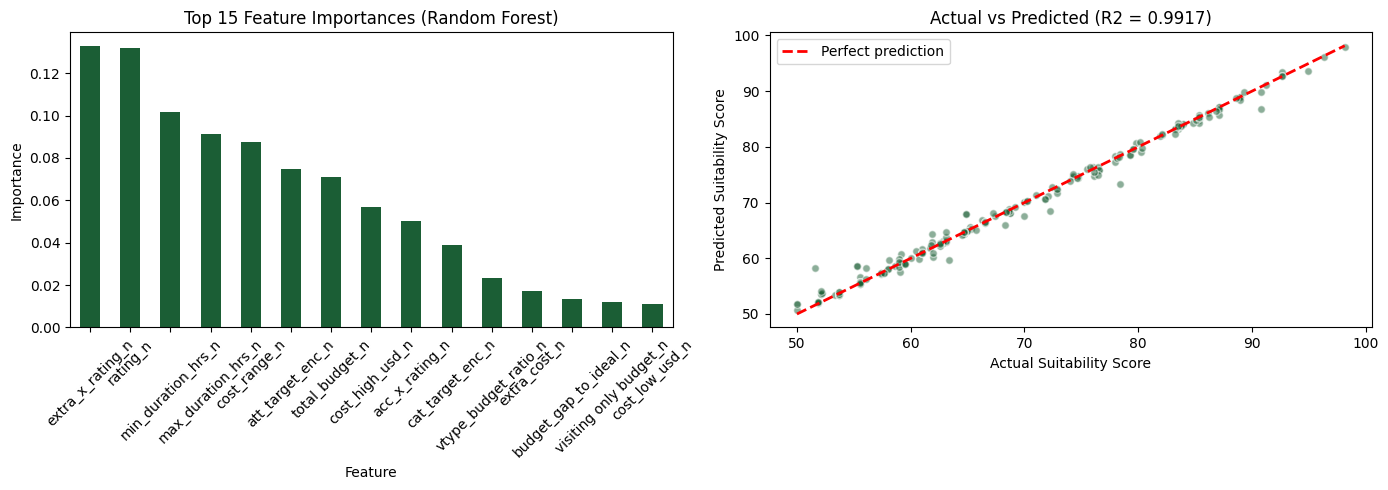

In [11]:
importances = pd.Series(rf.feature_importances_, index=RF_FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importances.head(15).plot(kind='bar', ax=axes[0], color='#1B5E35')
axes[0].set_title('Top 15 Feature Importances (Random Forest)')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=45)
axes[1].scatter(y_test, y_pred, alpha=0.5, color='#1B5E35', edgecolors='white', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Suitability Score')
axes[1].set_ylabel('Predicted Suitability Score')
axes[1].set_title(f'Actual vs Predicted (R2 = {test_r2:.4f})')
axes[1].legend()
plt.tight_layout()
plt.show()

## Section 9: Train KNN — Collaborative Filtering (20%)

In [12]:
KNN_FEATURES = ['accommodation_e','travel means_e','time spent_e',
                'season_e','visitor_type_e','acc_flag','twoday',
                'visiting_budget_norm','total_budget_norm','rating_norm']
knn_feats = [f for f in KNN_FEATURES if f in df.columns]
knn = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute', n_jobs=-1)
knn.fit(df[knn_feats].fillna(0))
print(f'KNN fitted on {len(df)} records')
print(f'KNN features used: {knn_feats}')
print('KNN training complete.')

KNN fitted on 1000 records
KNN features used: ['accommodation_e', 'travel means_e', 'time spent_e', 'season_e', 'visitor_type_e', 'acc_flag', 'twoday', 'visiting_budget_norm', 'total_budget_norm', 'rating_norm']
KNN training complete.


## Section 10: Accuracy, Precision, Recall and F1 Score

In [13]:
# Convert regression scores to classification labels for precision/recall/F1
# We define 3 classes based on suitability score:
#   Low    : score < 60
#   Medium : 60 <= score < 80
#   High   : score >= 80

def score_to_class(scores):
    labels = []
    for s in scores:
        if s < 60:
            labels.append('Low')
        elif s < 80:
            labels.append('Medium')
        else:
            labels.append('High')
    return labels

y_test_cls = score_to_class(y_test)
y_pred_cls = score_to_class(y_pred)

class_names = ['High', 'Low', 'Medium']

# Accuracy
acc = accuracy_score(y_test_cls, y_pred_cls)

# Precision, Recall, F1 (weighted average across all classes)
prec_w  = precision_score(y_test_cls, y_pred_cls, average='weighted', zero_division=0)
rec_w   = recall_score(y_test_cls, y_pred_cls, average='weighted', zero_division=0)
f1_w    = f1_score(y_test_cls, y_pred_cls, average='weighted', zero_division=0)

# Precision, Recall, F1 per class
prec_per = precision_score(y_test_cls, y_pred_cls, average=None, labels=class_names, zero_division=0)
rec_per  = recall_score(y_test_cls, y_pred_cls, average=None, labels=class_names, zero_division=0)
f1_per   = f1_score(y_test_cls, y_pred_cls, average=None, labels=class_names, zero_division=0)

print('=' * 60)
print('  CLASSIFICATION METRICS (Suitability Score Classes)')
print('  Low < 60  |  Medium 60-79  |  High >= 80')
print('=' * 60)
print(f'  Accuracy  (overall)  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision (weighted) : {prec_w:.4f}  ({prec_w*100:.2f}%)')
print(f'  Recall    (weighted) : {rec_w:.4f}  ({rec_w*100:.2f}%)')
print(f'  F1 Score  (weighted) : {f1_w:.4f}  ({f1_w*100:.2f}%)')
print()
print('  Per-Class Breakdown:')
print(f'  {"Class":<10} {"Precision":>12} {"Recall":>10} {"F1":>10}')
print(f'  {"-"*44}')
for i, cls in enumerate(class_names):
    print(f'  {cls:<10} {prec_per[i]:>12.4f} {rec_per[i]:>10.4f} {f1_per[i]:>10.4f}')
print('=' * 60)
print()
print('Full Classification Report:')
print(classification_report(y_test_cls, y_pred_cls, target_names=class_names, zero_division=0))

  CLASSIFICATION METRICS (Suitability Score Classes)
  Low < 60  |  Medium 60-79  |  High >= 80
  Accuracy  (overall)  : 0.9650  (96.50%)
  Precision (weighted) : 0.9653  (96.53%)
  Recall    (weighted) : 0.9650  (96.50%)
  F1 Score  (weighted) : 0.9650  (96.50%)

  Per-Class Breakdown:
  Class         Precision     Recall         F1
  --------------------------------------------
  High             0.9792     0.9592     0.9691
  Low              0.9474     0.9818     0.9643
  Medium           0.9684     0.9583     0.9634

Full Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.96      0.97        49
         Low       0.95      0.98      0.96        55
      Medium       0.97      0.96      0.96        96

    accuracy                           0.96       200
   macro avg       0.96      0.97      0.97       200
weighted avg       0.97      0.96      0.97       200



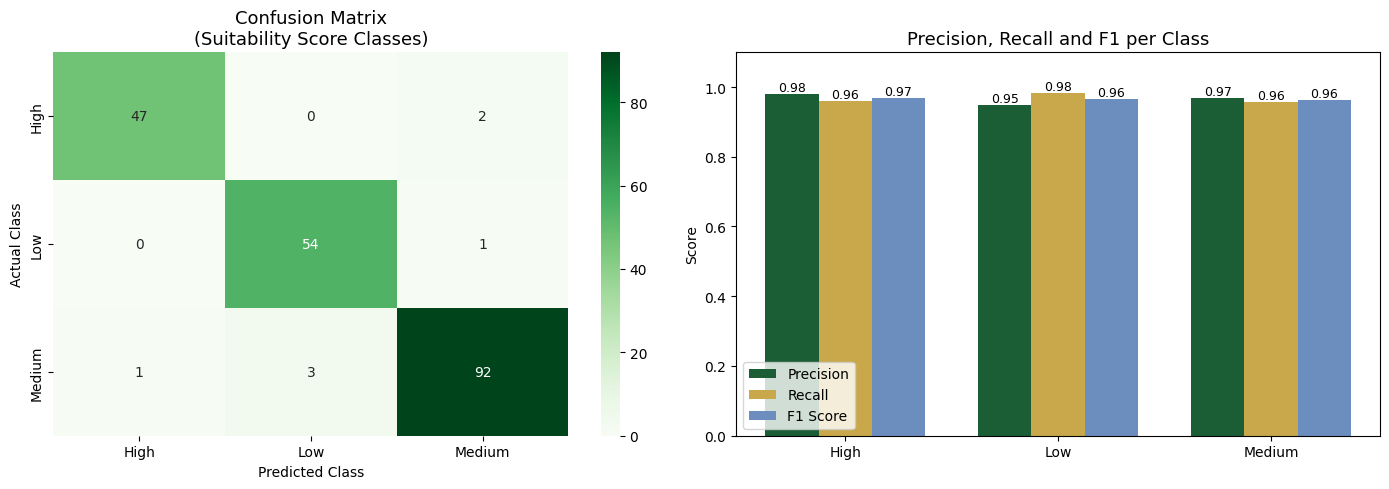

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_cls, labels=class_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix\n(Suitability Score Classes)', fontsize=13)
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('Actual Class')

# Bar chart: Precision, Recall, F1 per class
x = np.arange(len(class_names))
width = 0.25
axes[1].bar(x - width, prec_per, width, label='Precision', color='#1B5E35')
axes[1].bar(x,         rec_per,  width, label='Recall',    color='#C9A84C')
axes[1].bar(x + width, f1_per,   width, label='F1 Score',  color='#6c8ebf')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Precision, Recall and F1 per Class', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].legend()
for bar in axes[1].patches:
    axes[1].annotate(f'{bar.get_height():.2f}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

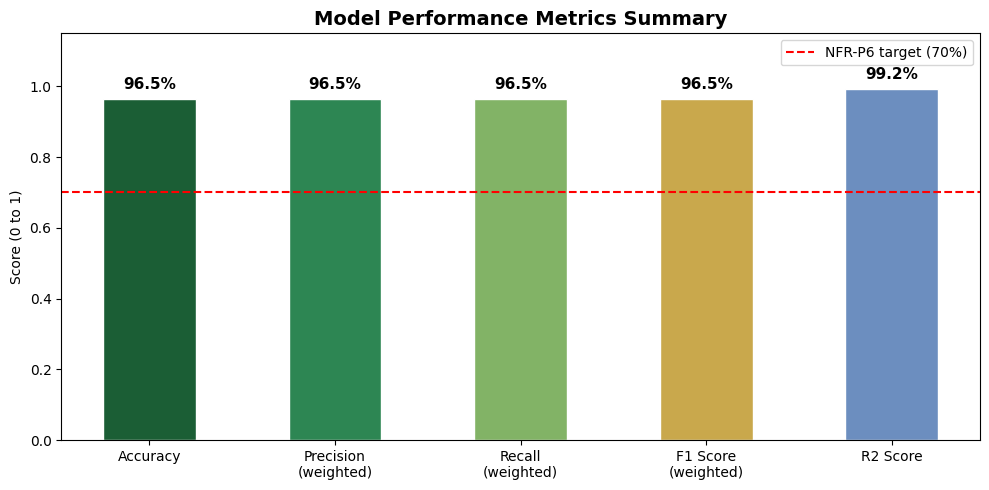

In [15]:
# Overall metrics bar chart
metrics = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1 Score\n(weighted)', 'R2 Score']
values  = [acc, prec_w, rec_w, f1_w, test_r2]
colors  = ['#1B5E35', '#2D8653', '#82b366', '#C9A84C', '#6c8ebf']

plt.figure(figsize=(10, 5))
bars = plt.bar(metrics, values, color=colors, edgecolor='white', width=0.5)
plt.ylim(0, 1.15)
plt.title('Model Performance Metrics Summary', fontsize=14, fontweight='bold')
plt.ylabel('Score (0 to 1)')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.axhline(y=0.70, color='red', linestyle='--', linewidth=1.5, label='NFR-P6 target (70%)')
plt.legend()
plt.tight_layout()
plt.show()

## Section 11: Final Evaluation Summary

In [16]:
print('=' * 55)
print('  FINAL MODEL EVALUATION SUMMARY')
print('=' * 55)
print(f'  Algorithm       : Hybrid (TF-IDF + RF + KNN)')
print(f'  Weights         : 55% CBF + 25% RF + 20% KNN')
print(f'  Total samples   : {len(df)}')
print(f'  Training set    : {len(X_train)} samples (80%)')
print(f'  Testing set     : {len(X_test)} samples (20%)')
print(f'  RF Features     : {len(RF_FEATURES)}')
print(f'  RF Estimators   : 200 trees')
print()
print(f'  --- Regression Metrics ---')
print(f'  R2 Score        : {test_r2:.4f} ({test_r2*100:.2f}%)')
print(f'  MAE             : {test_mae:.4f}')
print(f'  RMSE            : {test_rmse:.4f}')
print(f'  CV R2 (5-fold)  : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print()
print(f'  --- Classification Metrics ---')
print(f'  Accuracy        : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Precision       : {prec_w:.4f} ({prec_w*100:.2f}%)')
print(f'  Recall          : {rec_w:.4f} ({rec_w*100:.2f}%)')
print(f'  F1 Score        : {f1_w:.4f} ({f1_w*100:.2f}%)')
print()
print(f'  NFR-P6 (>=70%)  : {"PASSED" if test_r2 >= 0.70 else "FAILED"}')
print('=' * 55)

  FINAL MODEL EVALUATION SUMMARY
  Algorithm       : Hybrid (TF-IDF + RF + KNN)
  Weights         : 55% CBF + 25% RF + 20% KNN
  Total samples   : 1000
  Training set    : 800 samples (80%)
  Testing set     : 200 samples (20%)
  RF Features     : 37
  RF Estimators   : 200 trees

  --- Regression Metrics ---
  R2 Score        : 0.9917 (99.17%)
  MAE             : 0.6200
  RMSE            : 1.1184
  CV R2 (5-fold)  : 0.9913 +/- 0.0017

  --- Classification Metrics ---
  Accuracy        : 0.9650 (96.50%)
  Precision       : 0.9653 (96.53%)
  Recall          : 0.9650 (96.50%)
  F1 Score        : 0.9650 (96.50%)

  NFR-P6 (>=70%)  : PASSED


## Section 11: Save and Download Model Artifacts

In [17]:
version = datetime.now().strftime('%Y%m%d_%H%M%S')

# Learn visitor-type discounts
visitor_discounts = {}
for att, grp in df.groupby('area of attraction'):
    vt_avg = grp.groupby('visitor_type')['total_budget'].mean()
    intl   = vt_avg.get('international', vt_avg.mean())
    if intl == 0: intl = 1
    visitor_discounts[att] = {
        vt: max(0.0, round(1.0 - (vt_avg.get(vt, intl) / intl), 3))
        for vt in ['domestic','regional','international']
    }

# Save model bundle
bundle = dict(
    tfidf=tfidf, tfidf_matrix=matrix, cosine_sim=sim,
    attraction_index=idx, attraction_names=names,
    rf=rf, knn=knn, encoders=encoders, scaler=scaler,
    rf_feature_cols=RF_FEATURES, knn_features=knn_feats,
    cat_cols=CAT_COLS, num_raw=NUM_RAW, num_norm=NUM_NORM,
    att_target_mean=att_m.to_dict(), cat_target_mean=cat_m.to_dict(),
    prov_target_mean=prov_m.to_dict(), dist_target_mean=dist_m.to_dict(),
    visitor_discounts=visitor_discounts
)
with open('aits_model.pkl','wb') as f: pickle.dump(bundle, f)

# Save attraction profiles
profiles = (
    df.drop_duplicates('area of attraction')
    .set_index('area of attraction')
    [['attraction_id','category','province','district','location_desc',
      'description','activities','interest_tags',
      'cost_low_usd','cost_high_usd','min_duration_hrs','max_duration_hrs']]
    .to_dict(orient='index')
)
with open('attraction_profiles.json','w') as f: json.dump(profiles, f, indent=2)
with open('visitor_discounts.json','w') as f: json.dump(visitor_discounts, f, indent=2)

# Save metadata
meta = dict(
    model_id=f'aits-v{version}', version=version,
    training_date=datetime.now().isoformat(),
    record_count=len(df), attraction_count=df['area of attraction'].nunique(),
    train_size=len(X_train), test_size=len(X_test),
    rf_r2=round(float(test_r2),4), rf_mae=round(float(test_mae),4),
    rf_rmse=round(float(test_rmse),4),
    cv_r2_mean=round(float(cv_scores.mean()),4),
    cv_r2_std=round(float(cv_scores.std()),4),
    nfr_p6_met=bool(test_r2 >= 0.70),
    top_features=importances.head(8).to_dict(),
    is_active=True
)
with open('model_metadata.json','w') as f: json.dump(meta, f, indent=2)

print('Saved: aits_model.pkl')
print('Saved: attraction_profiles.json')
print('Saved: visitor_discounts.json')
print('Saved: model_metadata.json')

Saved: aits_model.pkl
Saved: attraction_profiles.json
Saved: visitor_discounts.json
Saved: model_metadata.json


In [18]:
# Download all files to your computer
from google.colab import files
files.download('aits_model.pkl')
files.download('attraction_profiles.json')
files.download('visitor_discounts.json')
files.download('model_metadata.json')
print('All files downloaded! Copy them to backend/models/ folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded! Copy them to backend/models/ folder.
